In [2]:
import re
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
import pandas as pd

stop_words = set(stopwords.words('russian'))
stemmer = SnowballStemmer('russian')

import pymorphy3
from nltk.corpus import stopwords
import re
from razdel import tokenize

import torch
import torch.nn as nn
import torch.optim as optim
from collections import Counter
import numpy as np

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [3]:
device = torch.device('cuda')

In [4]:
morph = pymorphy3.MorphAnalyzer()
russian_stopwords = set(stopwords.words('russian'))

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'[^а-яё\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

def tokenize_with_razdel(text):
    return [token.text for token in tokenize(text)]

def lemmatize_tokens(tokens):
    lemmas = []
    for token in tokens:
        parsed = morph.parse(token)[0]
        lemma = parsed.normal_form
        lemmas.append(lemma)
    return lemmas

def remove_stopwords(tokens):
    return [token for token in tokens if token not in russian_stopwords and len(token) > 2]

def full_text_preprocessing(text):
    cleaned_text = preprocess_text(text)
    tokens = tokenize_with_razdel(cleaned_text)
    lemmas = lemmatize_tokens(tokens)
    filtered_lemmas = remove_stopwords(lemmas)
    
    return filtered_lemmas


In [5]:
df = pd.read_csv('../lab_2/data/small_petitions.csv')
texts = df['public_petition_text'].apply(full_text_preprocessing)
texts

0       [газон, разбросать, различный, мусор, просьба,...
1                 [конструкция, препятствовать, парковка]
2       [лестница, убирать, месяц, просто, выливать, в...
3                           [мусор, задний, сторона, дом]
4       [снова, работать, уличный, фонарь, входной, дв...
                              ...                        
2995    [управлять, компания, лето, год, игнорировать,...
2996               [демонтировать, сомнительный, вывеска]
2997    [просить, установить, полусфера, защитить, газ...
2998    [работать, фонарь, освещение, подъезд, улгангу...
2999    [влажный, уборка, лестничный, клетка, производ...
Name: public_petition_text, Length: 3000, dtype: object

In [6]:
class Word2VecData:
    def __init__(self, texts, window_size=2):
        self.window_size = window_size
        self.vocab = self.build_vocab(texts)
        self.word_to_idx = {word: idx for idx, word in enumerate(self.vocab)}
        self.idx_to_word = {idx: word for idx, word in enumerate(self.vocab)}
        self.data = self.prepare_training_data(texts)
    
    def build_vocab(self, texts, min_freq=5):
        counter = Counter()
        for text in texts:
            counter.update(text)
        vocab = [word for word, count in counter.items() if count >= min_freq]
        return vocab
    
    def prepare_training_data(self, texts):
        data = []
        for text in texts:
            for i, target_word in enumerate(text):
                if target_word not in self.word_to_idx:
                    continue

                start = max(0, i - self.window_size)
                end = min(len(text), i + self.window_size + 1)
                context = [text[j] for j in range(start, end) 
                          if j != i and text[j] in self.word_to_idx]
                
                for context_word in context:
                    data.append((self.word_to_idx[target_word], 
                                self.word_to_idx[context_word]))
        return data

In [7]:
word2vec_data = Word2VecData(texts, window_size=2)
training_data = word2vec_data.data
vocab_size = len(word2vec_data.vocab)
word_to_idx = word2vec_data.word_to_idx

print(f"Размер словаря: {vocab_size}")
print(f"Количество обучающих примеров: {len(training_data)}")
print(f"Пример данных: {training_data[:5]}")

Размер словаря: 979
Количество обучающих примеров: 60136
Пример данных: [(0, 1), (0, 2), (1, 0), (1, 2), (1, 3)]


In [8]:
class CBOW(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.linear = nn.Linear(embedding_dim, vocab_size)
        
    def forward(self, inputs):
        embeds = self.embeddings(inputs)
        mean_embeds = torch.mean(embeds, dim=1)
        output = self.linear(mean_embeds)
        return output

class SkipGram(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.in_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.out_embeddings = nn.Embedding(vocab_size, embedding_dim)
        
    def forward(self, target_word):
        input_embeds = self.in_embeddings(target_word)
        output_embeds = self.out_embeddings.weight
        scores = torch.matmul(input_embeds, output_embeds.t())
        return scores

In [9]:
embedding_dim = 100
cbow_model = CBOW(vocab_size, embedding_dim)
skipgram_model = SkipGram(vocab_size, embedding_dim)

In [10]:
def train_word2vec(model, data, epochs=50, batch_size=512, learning_rate=0.01):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    data_np = np.array(data)
    
    for epoch in range(epochs):
        total_loss = 0
        num_batches = 0
        
        np.random.shuffle(data_np)
        
        for i in range(0, len(data_np), batch_size):
            batch = data_np[i:i + batch_size]
            
            if len(batch) == 0:
                continue
                
            if isinstance(model, CBOW):
                targets, contexts = batch[:, 0], batch[:, 1]
                inputs = torch.tensor(contexts, dtype=torch.long).to(device).unsqueeze(1)
                targets = torch.tensor(targets, dtype=torch.long).to(device)
            else:
                targets, contexts = batch[:, 0], batch[:, 1]
                inputs = torch.tensor(targets, dtype=torch.long).to(device)
                targets = torch.tensor(contexts, dtype=torch.long).to(device)
            
            optimizer.zero_grad()
            output = model(inputs)
            loss = criterion(output, targets)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            num_batches += 1

        avg_loss = total_loss / num_batches if num_batches > 0 else total_loss
        print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}')
    
    model.to('cpu')
    return model

In [11]:
print("Обучение CBOW...")
train_word2vec(cbow_model, training_data)

Обучение CBOW...
Epoch 1/50, Loss: 6.1064
Epoch 2/50, Loss: 5.2279
Epoch 3/50, Loss: 4.9511
Epoch 4/50, Loss: 4.7894
Epoch 5/50, Loss: 4.6819
Epoch 6/50, Loss: 4.6029
Epoch 7/50, Loss: 4.5422
Epoch 8/50, Loss: 4.4993
Epoch 9/50, Loss: 4.4600
Epoch 10/50, Loss: 4.4284
Epoch 11/50, Loss: 4.4034
Epoch 12/50, Loss: 4.3855
Epoch 13/50, Loss: 4.3670
Epoch 14/50, Loss: 4.3514
Epoch 15/50, Loss: 4.3379
Epoch 16/50, Loss: 4.3264
Epoch 17/50, Loss: 4.3163
Epoch 18/50, Loss: 4.3071
Epoch 19/50, Loss: 4.2989
Epoch 20/50, Loss: 4.2939
Epoch 21/50, Loss: 4.2874
Epoch 22/50, Loss: 4.2808
Epoch 23/50, Loss: 4.2760
Epoch 24/50, Loss: 4.2700
Epoch 25/50, Loss: 4.2646
Epoch 26/50, Loss: 4.2622
Epoch 27/50, Loss: 4.2585
Epoch 28/50, Loss: 4.2534
Epoch 29/50, Loss: 4.2501
Epoch 30/50, Loss: 4.2479
Epoch 31/50, Loss: 4.2463
Epoch 32/50, Loss: 4.2419
Epoch 33/50, Loss: 4.2378
Epoch 34/50, Loss: 4.2331
Epoch 35/50, Loss: 4.2341
Epoch 36/50, Loss: 4.2303
Epoch 37/50, Loss: 4.2309
Epoch 38/50, Loss: 4.2283
Epoc

CBOW(
  (embeddings): Embedding(979, 100)
  (linear): Linear(in_features=100, out_features=979, bias=True)
)

In [12]:
print("Обучение SkipGram...")
train_word2vec(skipgram_model, training_data)

Обучение SkipGram...
Epoch 1/50, Loss: 19.3608
Epoch 2/50, Loss: 10.7207
Epoch 3/50, Loss: 7.9219
Epoch 4/50, Loss: 6.5651
Epoch 5/50, Loss: 5.8279
Epoch 6/50, Loss: 5.3860
Epoch 7/50, Loss: 5.1030
Epoch 8/50, Loss: 4.9173
Epoch 9/50, Loss: 4.7865
Epoch 10/50, Loss: 4.6920
Epoch 11/50, Loss: 4.6202
Epoch 12/50, Loss: 4.5690
Epoch 13/50, Loss: 4.5273
Epoch 14/50, Loss: 4.4932
Epoch 15/50, Loss: 4.4653
Epoch 16/50, Loss: 4.4429
Epoch 17/50, Loss: 4.4252
Epoch 18/50, Loss: 4.4090
Epoch 19/50, Loss: 4.3942
Epoch 20/50, Loss: 4.3854
Epoch 21/50, Loss: 4.3697
Epoch 22/50, Loss: 4.3596
Epoch 23/50, Loss: 4.3535
Epoch 24/50, Loss: 4.3461
Epoch 25/50, Loss: 4.3345
Epoch 26/50, Loss: 4.3312
Epoch 27/50, Loss: 4.3214
Epoch 28/50, Loss: 4.3173
Epoch 29/50, Loss: 4.3115
Epoch 30/50, Loss: 4.3049
Epoch 31/50, Loss: 4.3014
Epoch 32/50, Loss: 4.2980
Epoch 33/50, Loss: 4.2919
Epoch 34/50, Loss: 4.2864
Epoch 35/50, Loss: 4.2811
Epoch 36/50, Loss: 4.2818
Epoch 37/50, Loss: 4.2761
Epoch 38/50, Loss: 4.271

SkipGram(
  (in_embeddings): Embedding(979, 100)
  (out_embeddings): Embedding(979, 100)
)

In [13]:
def visualize_embeddings(model, word_to_idx, words_to_visualize=None):
    if words_to_visualize is None:
        words_to_visualize = list(word_to_idx.keys())[:30]

    if isinstance(model, CBOW):
        embeddings = model.embeddings.weight.data.numpy()
    else:
        embeddings = model.in_embeddings.weight.data.numpy()

    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings)

    plt.figure(figsize=(15, 10))
    
    for word in words_to_visualize:
        if word in word_to_idx:
            idx = word_to_idx[word]
            x, y = embeddings_2d[idx]
            plt.scatter(x, y, s=100, alpha=0.7)
            plt.annotate(word, (x, y), xytext=(5, 5), textcoords='offset points', 
                        fontsize=12, alpha=0.8)
    
    plt.title('Визуализация векторных представлений слов (PCA)', fontsize=16)
    plt.xlabel('Первая главная компонента')
    plt.ylabel('Вторая главная компонента')
    plt.grid(True, alpha=0.3)
    plt.show()

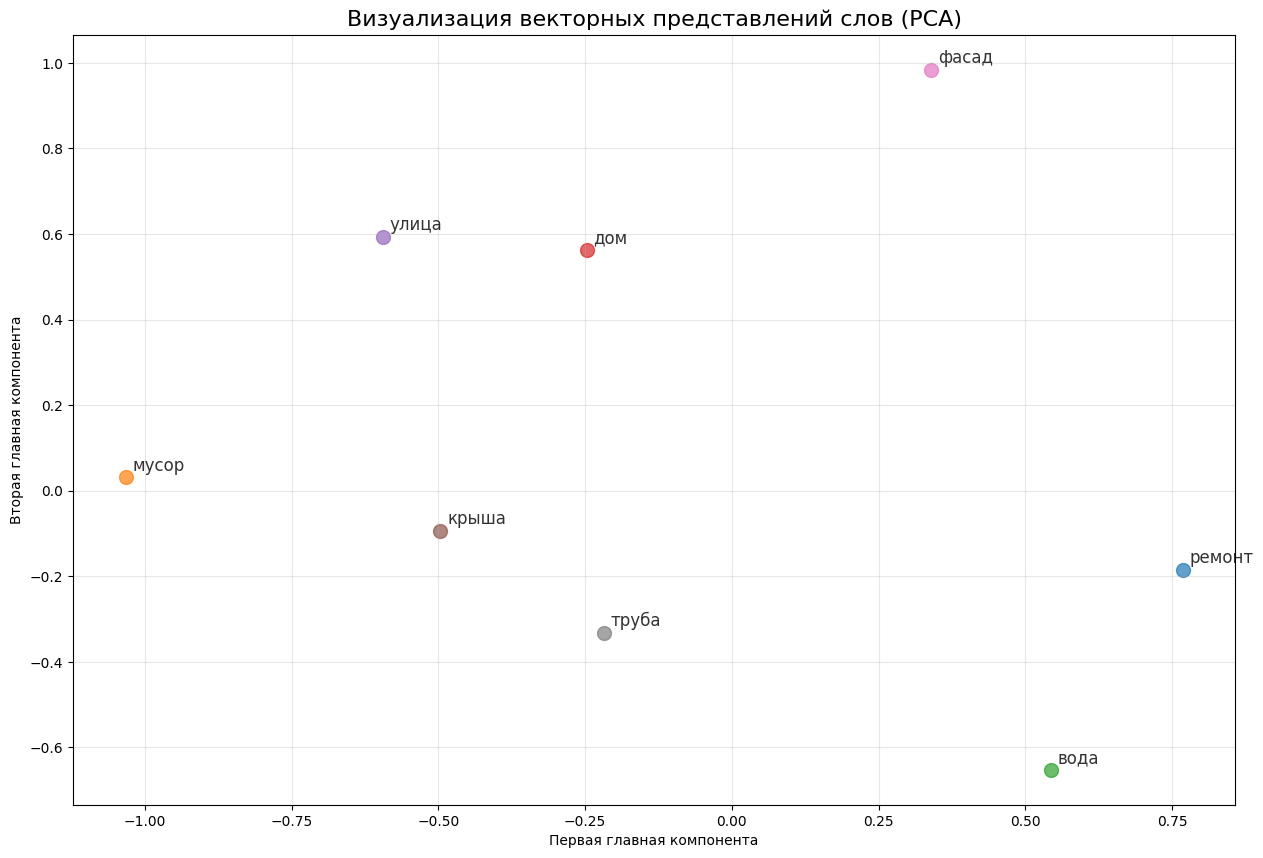

In [14]:
test_words = ['ремонт', 'мусор', 'вода', 'дом', 'улица', 'крыша', 'фасад', 'труба', 'электричество']
visualize_embeddings(cbow_model, word_to_idx, test_words)

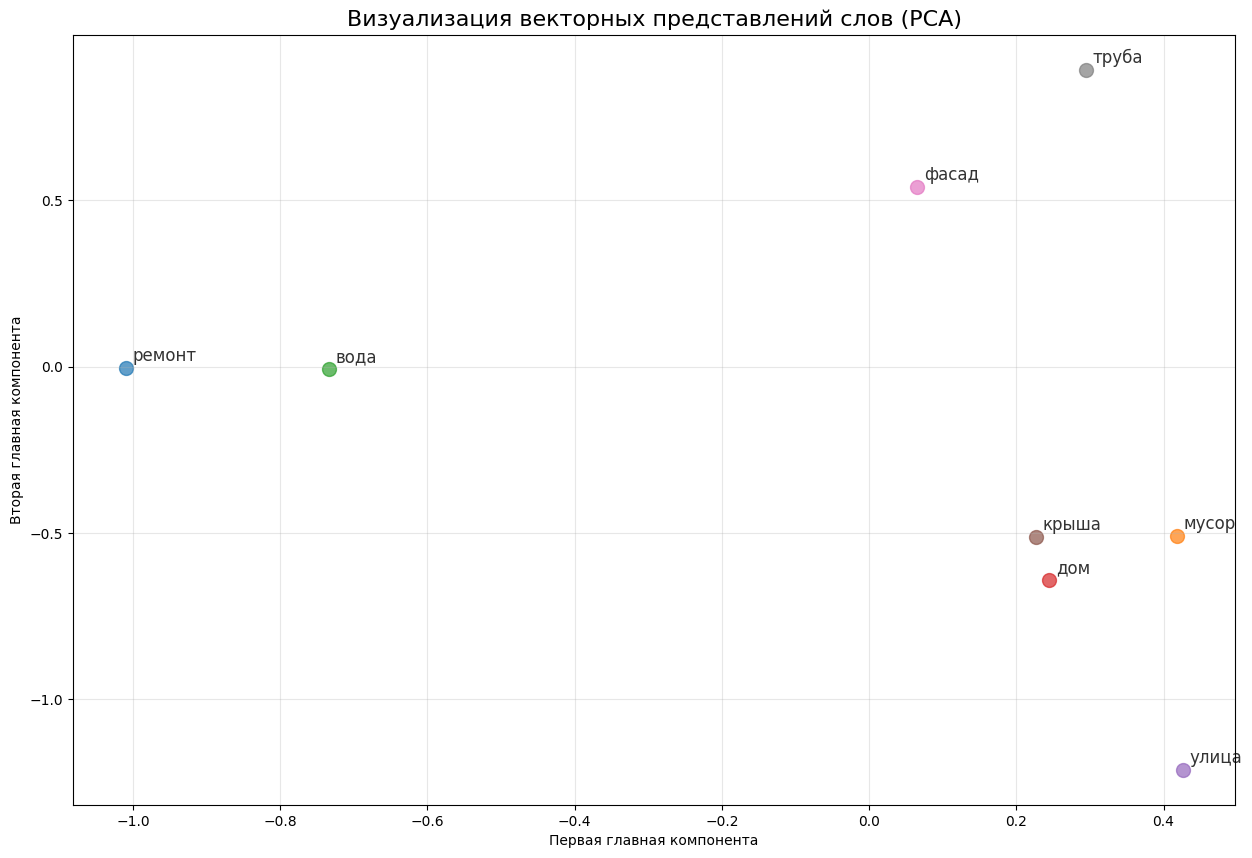

In [15]:
test_words = ['ремонт', 'мусор', 'вода', 'дом', 'улица', 'крыша', 'фасад', 'труба', 'электричество']
visualize_embeddings(skipgram_model, word_to_idx, test_words)

In [16]:
def get_similar_words(embeddings, target_idx, topn):
    target_embedding = embeddings[target_idx]
    similarities = []
    
    for idx, embedding in enumerate(embeddings):
        if idx != target_idx:
            similarity = np.dot(target_embedding, embedding) / (
                np.linalg.norm(target_embedding) * np.linalg.norm(embedding))
            similarities.append((idx_to_word[idx], similarity))
    
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:topn]

def compare_models_similarities(cbow_model, skipgram_model, word, word_to_idx, topn=5):
    if word not in word_to_idx:
        return f"Слово '{word}' не найдено в словаре"

    cbow_embeddings = cbow_model.embeddings.weight.data.numpy()
    skipgram_embeddings = skipgram_model.in_embeddings.weight.data.numpy()
    
    target_idx = word_to_idx[word]

    cbow_similar = get_similar_words(cbow_embeddings, target_idx, topn)
    skipgram_similar = get_similar_words(skipgram_embeddings, target_idx, topn)

    print(f"\nСравнение похожих слов для '{word}':")
    print("=" * 65)
    print(f"{'#':<2} {'CBOW':<20} {'Сходство':<10} {'SkipGram':<20} {'Сходство':<10}")
    print("-" * 65)
    
    for i in range(topn):
        cbow_word, cbow_sim = cbow_similar[i] if i < len(cbow_similar) else ("-", 0)
        skipgram_word, skipgram_sim = skipgram_similar[i] if i < len(skipgram_similar) else ("-", 0)
        
        print(f"{i+1:<2} {cbow_word:<20} {cbow_sim:<10.3f} {skipgram_word:<20} {skipgram_sim:<10.3f}")

idx_to_word = {idx: word for word, idx in word_to_idx.items()}

In [17]:
compare_models_similarities(cbow_model, skipgram_model, "ремонт", word_to_idx)


Сравнение похожих слов для 'ремонт':
#  CBOW                 Сходство   SkipGram             Сходство  
-----------------------------------------------------------------
1  текущий              0.326      восстановление       0.376     
2  отремонтировать      0.315      замена               0.321     
3  выполнить            0.303      восстановить         0.305     
4  карниз               0.299      содержание           0.305     
5  батарея              0.298      соседний             0.304     


In [18]:
for word in ['ремонт', 'мусор', 'вода']:
    compare_models_similarities(cbow_model, skipgram_model, word, word_to_idx)


Сравнение похожих слов для 'ремонт':
#  CBOW                 Сходство   SkipGram             Сходство  
-----------------------------------------------------------------
1  текущий              0.326      восстановление       0.376     
2  отремонтировать      0.315      замена               0.321     
3  выполнить            0.303      восстановить         0.305     
4  карниз               0.299      содержание           0.305     
5  батарея              0.298      соседний             0.304     

Сравнение похожих слов для 'мусор':
#  CBOW                 Сходство   SkipGram             Сходство  
-----------------------------------------------------------------
1  валяться             0.375      валяться             0.419     
2  листва               0.365      лист                 0.411     
3  окурок               0.353      листва               0.404     
4  свалка               0.299      газон                0.363     
5  железобетонный       0.287      покрышка             

In [19]:
def save_embeddings_for_projector(model, word_to_idx, filename):
    if isinstance(model, CBOW):
        embeddings = model.embeddings.weight.data.numpy()
    else:
        embeddings = model.in_embeddings.weight.data.numpy()

    sorted_words = sorted(word_to_idx.items(), key=lambda x: x[1])

    valid_words = []
    for word, idx in sorted_words:
        if idx < len(embeddings):
            valid_words.append(word)

    np.savetxt(f'{filename}_vectors.tsv', embeddings, delimiter='\t')

    with open(f'{filename}_metadata.tsv', 'w', encoding='utf-8') as f:
        for word in valid_words:
            f.write(f'{word}\n')

In [20]:
save_embeddings_for_projector(cbow_model, word_to_idx, 'cbow_embeddings')
save_embeddings_for_projector(skipgram_model, word_to_idx, 'skipgram_embeddings')

In [21]:
def get_text_embeddings(model, texts, word_to_idx, aggregation='mean'):
    if isinstance(model, CBOW):
        word_vectors = model.embeddings.weight.data.numpy()
    else:
        word_vectors = model.in_embeddings.weight.data.numpy()
    
    text_embeddings = []
    
    for text in texts:
        word_indices = [word_to_idx[word] for word in text if word in word_to_idx]
        
        if not word_indices:
            text_emb = np.zeros(word_vectors.shape[1])
        else:
            word_embs = word_vectors[word_indices]

            if aggregation == 'mean':
                text_emb = np.mean(word_embs, axis=0)
            elif aggregation == 'sum':
                text_emb = np.sum(word_embs, axis=0)
            else:
                text_emb = np.mean(word_embs, axis=0)
        
        text_embeddings.append(text_emb)
    
    return np.array(text_embeddings)

In [23]:
cbow_text_embeddings = get_text_embeddings(cbow_model, texts, word_to_idx, 'mean')
skipgram_text_embeddings = get_text_embeddings(skipgram_model, texts, word_to_idx, 'mean')

In [24]:
def reduce_dimensionality(embeddings, n_components=2):
    pca = PCA(n_components=n_components)
    reduced_embeddings = pca.fit_transform(embeddings)
    
    print(f"PCA: {embeddings.shape[1]}D → {n_components}D")
    print(f"Объясненная дисперсия: {np.sum(pca.explained_variance_ratio_):.3f}")
    
    return reduced_embeddings, pca

In [25]:
cbow_2d, cbow_pca = reduce_dimensionality(cbow_text_embeddings, n_components=2)
skipgram_2d, skipgram_pca = reduce_dimensionality(skipgram_text_embeddings, n_components=2)

PCA: 100D → 2D
Объясненная дисперсия: 0.161
PCA: 100D → 2D
Объясненная дисперсия: 0.153


In [28]:
def visualize_text_embeddings(embeddings_2d, labels, title, categories=None):
    plt.figure(figsize=(12, 8))
    
    if categories is not None:
        unique_categories = list(set(categories))
        colors = plt.cm.Set3(np.linspace(0, 1, len(unique_categories)))
        
        for i, category in enumerate(unique_categories):
            mask = np.array(categories) == category
            plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], 
                       c=[colors[i]], label=category, alpha=0.7, s=50)
    else:
        plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.7, s=30)
    
    plt.title(f'{title} (2D PCA)')
    plt.xlabel('Первая главная компонента')
    plt.ylabel('Вторая главная компонента')
    plt.grid(True, alpha=0.3)
    plt.show()

try:
    categories = df['reason_category'].values
    has_categories = True
except:
    categories = None
    has_categories = False

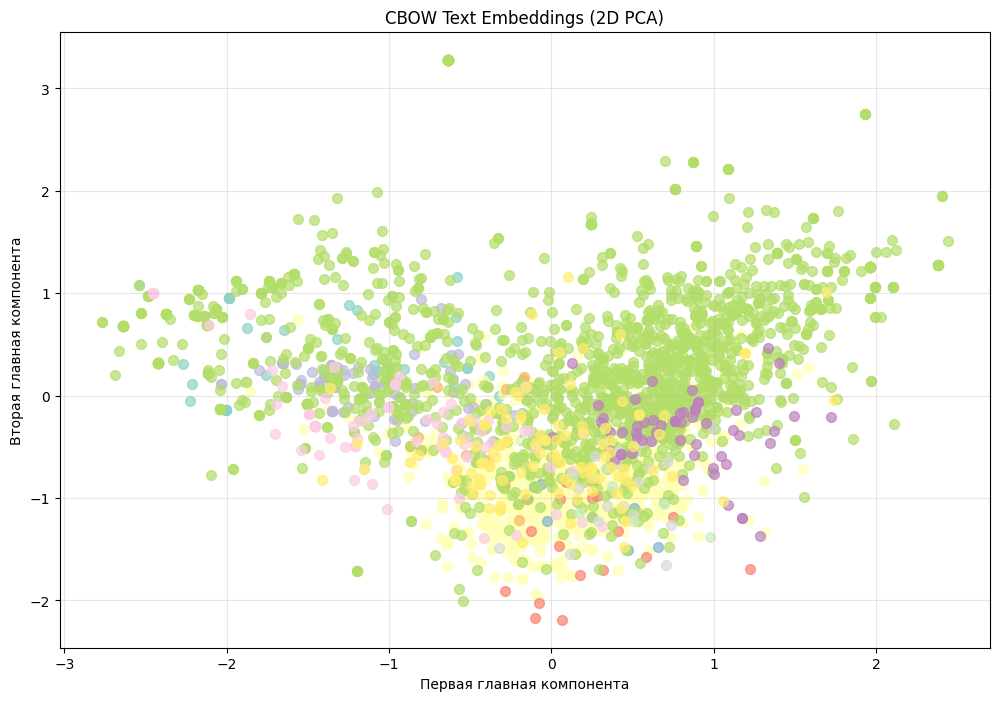

In [29]:

visualize_text_embeddings(cbow_2d, texts, 'CBOW Text Embeddings', categories)

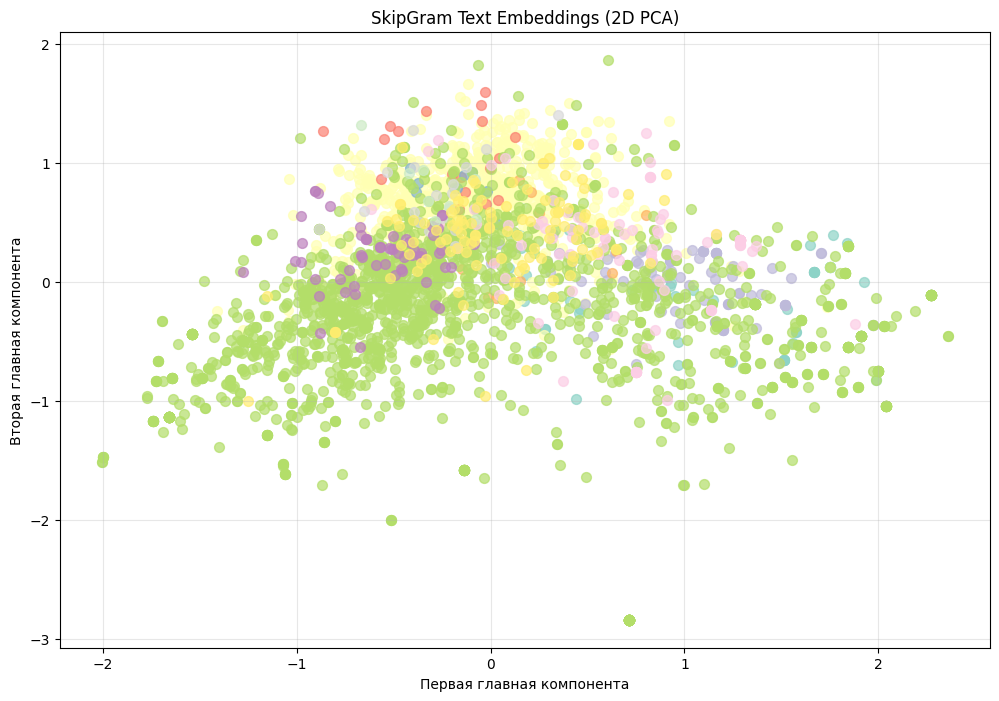

In [30]:
visualize_text_embeddings(skipgram_2d, texts, 'SkipGram Text Embeddings', categories)